# Prueba práctica Analista de datos - Primer punto
 
Pragma desea empezar a trabajar con una marca que presta servicios de banca digital a otras empresas. Dicha marca tiene dentro de sus objetivos 
como negocio incrementar sus comisiones por utilizar su API de pago en un 50% para el 2022, ellos ganan un 5% de cada transacción que se realice a través de la APP.  

Internamente saben que mucho de este crecimiento debe estar bajo 
estrategias de medios apoyadas en datos, por lo que Pragma le propone 
segmentar a sus clientes actuales (Comercios y Transacciones) para poder 
hacer un mejor entendimiento de quiénes son los mejores y la categoría a la 
que pertenecen estos, así poder crear campañas de marketing mejor 
segmentadas. 

Para lograr esto, su reto como analista de datos es entender la información 
entregada, analizarla para los últimos 6 meses y lograr una segmentación de 
los comercios activos en ese periodo de tiempo. 

El cliente le solicita que: 

a. Describa el modelo de segmentación implementado y los resultados 
que obtuvo. 

b. ¿Qué KPIs y métricas recomienda para hacer un seguimiento al 
cumplimiento del objetivo? 

c. Haga un tablero dónde se logre visualizar el historial de las métricas y 
KPIs de acuerdo a la información suministrada y el resultado del 
modelo. 

## 1. Carga de datos

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

In [2]:
RUTA_DATOS = "DataTransacciones_PruebasIngreso.xlsx"

xls = pd.ExcelFile(RUTA_DATOS)
df_comercios = xls.parse("comercios")
df_transacciones = xls.parse("transacciones")

In [3]:
print("comercios:", df_comercios.shape)
print("transacciones:", df_transacciones.shape)

comercios: (3071, 10)
transacciones: (8357, 3)


In [4]:
df_comercios.head()

,Id_comercio,Fecha vinculación datafono,Fecha de creacion comercio,Categoria comercio,Sub Categoria comercio,Id_terminal,Ciudad,Fecha 1ra_transaccion,Monto ventas Acumulado,Monto ventas ultimo mes
0,003QDVFJCJ,"mar. 26, 2021 12:40pm","mar. 26, 2021 12:17pm",Comercio detallista,Ropa / Accesorios,1299,Bogotá D.C.,"mar. 26, 2021 12:42pm",6542000,1240000
1,008LJH6YHN,"feb. 10, 2021 3:31pm","feb. 10, 2021 3:15pm",Belleza y cuidado personal,Spa,591,Bogotá D.C.,"feb. 10, 2021 3:34pm",4380000,1102000
2,00B3DGV62G,"mar. 3, 2021 3:26pm","mar. 3, 2021 3:09pm",Comercio detallista,Auto partes,2130,Bogotá D.C.,"mar. 3, 2021 3:30pm",11892500,1297000
3,00ILW1BB3Y,"mar. 24, 2021 12:45pm","mar. 24, 2021 12:33pm",Comercio detallista,Tienda naturista,662,Bogotá D.C.,"mar. 24, 2021 12:51pm",372500,74500
4,01AK7UX4UU,"mar. 30, 2021 1:50pm","mar. 30, 2021 1:40pm",Comercio detallista,Tecnología,1784,Mosquera,"mar. 30, 2021 1:52pm",165500,0


In [5]:
df_comercios.dtypes

Id_comercio                     str
Fecha vinculación datafono      str
Fecha de creacion comercio      str
Categoria comercio              str
Sub Categoria comercio          str
Id_terminal                   int64
Ciudad                          str
Fecha 1ra_transaccion           str
Monto ventas Acumulado        int64
Monto ventas ultimo mes       int64
dtype: object

In [6]:
df_transacciones.head()

,Id_comercio,mes-anio transaccion,cantidad transacciones
0,003QDVFJCJ,3-2021,5
1,003QDVFJCJ,4-2021,9
2,003QDVFJCJ,5-2021,16
3,008LJH6YHN,2-2021,2
4,008LJH6YHN,3-2021,5


In [7]:
df_transacciones.dtypes

Id_comercio                 str
mes-anio transaccion        str
cantidad transacciones    int64
dtype: object

## 2. Análisis exploratorio de datos (EDA)

### 2.1 Nulos por columna

In [8]:
print("Nulos en comercios:")
print(df_comercios.isnull().sum())
print()
print("Nulos en transacciones:")
print(df_transacciones.isnull().sum())

Nulos en comercios:
Id_comercio                    0
Fecha vinculación datafono     0
Fecha de creacion comercio     0
Categoria comercio             0
Sub Categoria comercio         0
Id_terminal                    0
Ciudad                         0
Fecha 1ra_transaccion         21
Monto ventas Acumulado         0
Monto ventas ultimo mes        0
dtype: int64

Nulos en transacciones:
Id_comercio               0
mes-anio transaccion      0
cantidad transacciones    0
dtype: int64


Podemos observar, que solo la columna de `Fecha 1ra_transaccion` de comercios tiene 21 valores nulos. Esto se investigará más adelante.

### 2.2 Estadísticas descriptivas generales

In [9]:
df_comercios.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id_comercio,3071,3015,9WEPENSRWI,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fecha vinculación datafono,3071,2895,"mar. 23, 2021 1:07pm",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fecha de creacion comercio,3071,2838,"ene. 21, 2021 4:20pm",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Categoria comercio,3071,8,Comercio detallista,1656,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub Categoria comercio,3071,71,Otro,420,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Id_terminal,3071.0,NaN,NaN,NaN,1542.891241,888.929849,1.0,774.0,1543.0,2312.5,3080.0
Ciudad,3071,64,Bogotá D.C.,2476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fecha 1ra_transaccion,3050,2878,"mar. 16, 2021 3:01pm",10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monto ventas Acumulado,3071.0,NaN,NaN,NaN,4308254.74829,7588705.899616,0.0,307000.0,1527500.0,4863800.0,80330200.0
Monto ventas ultimo mes,3071.0,NaN,NaN,NaN,657546.776294,1514032.577555,0.0,0.0,103550.0,671000.0,32650000.0


In [10]:
df_transacciones.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id_comercio,8357,3015,0UE0G86TAF,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mes-anio transaccion,8357,6,3-2021,2737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cantidad transacciones,8357.0,NaN,NaN,NaN,8.15508,14.537373,1.0,2.0,4.0,9.0,248.0


`Id_comercio` en `df_comercios` tiene 3071 filas pero solo 3015 valores únicos, es decir que hay duplicados. Se profundizará más adelante.

### 2.3 Variables categóricas

In [11]:
cat_cols_comercios = ["Categoria comercio", "Sub Categoria comercio", "Ciudad"]

for c in cat_cols_comercios:
    print(f"--- {c} (valores únicos = {df_comercios[c].nunique()}) ---")
    print(df_comercios[c].value_counts(dropna=False))
    print()

--- Categoria comercio (valores únicos = 8) ---
Categoria comercio
Comercio detallista           1656
Servicios                      525
Alimentos y bebidas            390
Belleza y cuidado personal     210
Reparación y limpieza          168
Transporte                      76
Turismo y entretenimiento       36
Educación                       10
Name: count, dtype: int64

--- Sub Categoria comercio (valores únicos = 71) ---
Sub Categoria comercio
Otro                          420
Óptica                        333
Ropa / Accesorios             332
Tecnología                    177
Materiales de construcción    114
                             ... 
Alquiler de vehículos           2
Mudanza                         1
Jardín infantil                 1
Perfumería                      1
Tutor / Profesor                1
Name: count, Length: 71, dtype: int64

--- Ciudad (valores únicos = 64) ---
Ciudad
Bogotá  D.C.    2476
Soacha           182
Cali             107
Fusagasugá        39
Chía     

In [12]:
cat_cols_transacciones = ["mes-anio transaccion"]

for c in cat_cols_transacciones:
    print(f"--- {c} (valores únicos = {df_transacciones[c].nunique()}) ---")
    print(df_transacciones[c].value_counts(dropna=False))
    print()

--- mes-anio transaccion (valores únicos = 6) ---
mes-anio transaccion
3-2021     2737
4-2021     2095
5-2021     2087
2-2021      887
1-2021      353
12-2020     198
Name: count, dtype: int64



**Observaciones:**
- `Categoria comercio`:  
Tiene 8 categorías únicas. "Comercio detallista" tiene el 54% (1656 de 3071), más de la mitad.  
Categorías como "Educación" (10) y "Turismo y entretenimiento" (36) tienen muestras muy pequeñas; cualquier conclusión "por categoría" sobre ellas debe hacerse con precaución.

- `Sub Categoria comercio`:  
Tiene 71 valores únicos, muy distribuida, con "Otro" como la más común (420, 14%) y una cola larga de subcategorías con 1-2 comercios.

- `Ciudad`:  
Concentración altísima: Bogotá D.C. es el 80.6% del total.
El resto son 63 ciudades, muchas con 1 solo comercio. `Ciudad` no es una buena variable para el modelo de clustering (casi todo es una sola categoría), pero sí nos servirá como filtro en el tablero.


- `mes-anio transaccion`:  
Confirma los 6 meses.

In [13]:
print("Ciudades con un solo comercio:", (df_comercios["Ciudad"].value_counts() == 1).sum(), "de", df_comercios["Ciudad"].nunique())

Ciudades con un solo comercio: 30 de 64


### 2.4 Variables numéricas

In [14]:
num_cols_comercios = ["Id_terminal", "Monto ventas Acumulado", "Monto ventas ultimo mes"]

for c in num_cols_comercios:
    print(f"--- {c} ---")
    print(df_comercios[c].describe())
    print()

--- Id_terminal ---
count    3071.000000
mean     1542.891241
std       888.929849
min         1.000000
25%       774.000000
50%      1543.000000
75%      2312.500000
max      3080.000000
Name: Id_terminal, dtype: float64

--- Monto ventas Acumulado ---
count    3.071000e+03
mean     4.308255e+06
std      7.588706e+06
min      0.000000e+00
25%      3.070000e+05
50%      1.527500e+06
75%      4.863800e+06
max      8.033020e+07
Name: Monto ventas Acumulado, dtype: float64

--- Monto ventas ultimo mes ---
count    3.071000e+03
mean     6.575468e+05
std      1.514033e+06
min      0.000000e+00
25%      0.000000e+00
50%      1.035500e+05
75%      6.710000e+05
max      3.265000e+07
Name: Monto ventas ultimo mes, dtype: float64



In [15]:
print("--- cantidad transacciones ---")
print(df_transacciones["cantidad transacciones"].describe())

--- cantidad transacciones ---
count    8357.000000
mean        8.155080
std        14.537373
min         1.000000
25%         2.000000
50%         4.000000
75%         9.000000
max       248.000000
Name: cantidad transacciones, dtype: float64


`Monto ventas Acumulado` y `cantidad transacciones` están muy sesgados a la derecha (media(mean) muy por encima de la mediana(50%), con máximos muy altos). Esto se puede confirmar visualmente en la siguiente celda y se manejará con transformación logarítmica en el modelado.

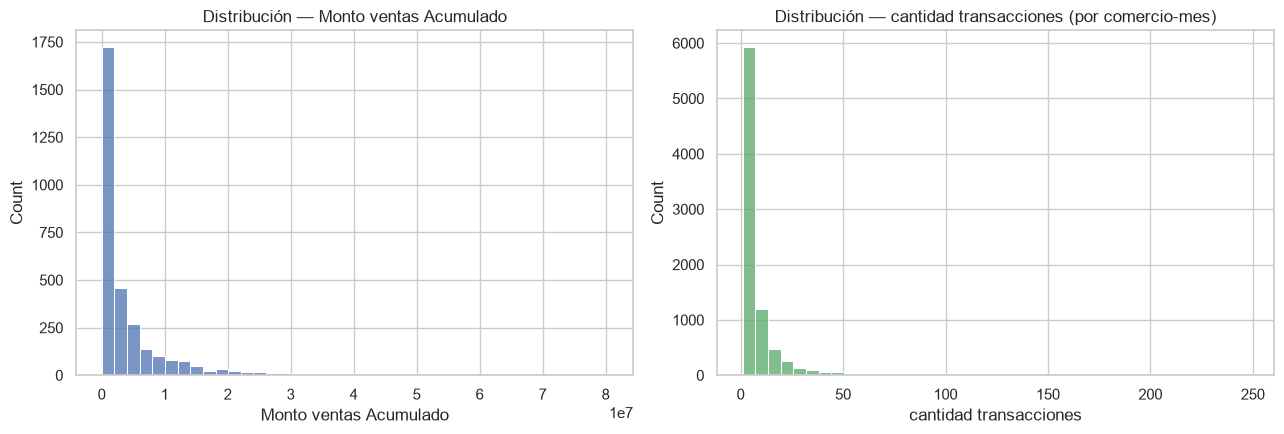

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df_comercios["Monto ventas Acumulado"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución — Monto ventas Acumulado")
sns.histplot(df_transacciones["cantidad transacciones"], bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Distribución — cantidad transacciones (por comercio-mes)")
plt.tight_layout()
plt.show()

### 2.5 Valores atípicos (outliers) e inconsistencias